In [10]:
pip install nbformat kaleido


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Титульный блок

# Анализ и постановка задачи бинарной классификации фейковых новостей

**Дисциплина:** Машинное обучение  
**Студент:** Нечепаев Денис  
**Статус:** студент 3 курса  
**Направление:** Бизнес-информатика


## 2. Постановка бизнес-задачи

Для новостных платформ, медиа и социальных сервисов фейковые публикации создают прикладную операционную проблему. Если недостоверный материал попадает в ленту и быстро распространяется, платформа теряет доверие аудитории, получает репутационный ущерб и увеличивает нагрузку на команду модерации. Для редакции или агрегатора это означает рост операционных затрат: чем больше поток контента, тем сложнее опираться только на ручную проверку.

Практическая цель такой системы — не заменить редактора, а построить модуль предварительной фильтрации, который автоматически выделяет публикации с высоким риском недостоверности и отправляет их в очередь ручной проверки. В этой логике ошибки модели имеют разную цену. Пропуск фейковой новости критичнее, потому что материал проходит дальше по процессу и начинает распространяться до вмешательства человека. Ложное срабатывание на реальную новость тоже нежелательно, но оно ограничивается дополнительной проверкой и не создаёт немедленного репутационного ущерба.

Для операционной оценки можно принять простой условный сценарий: через систему проходит около 1000 материалов в день, а команда модерации способна вручную проверить примерно 200–250 публикаций. Если модель отправляет на проверку 200 материалов при `Precision(fake) = 0.75`, то около 150 из них действительно будут подозрительными, а около 50 окажутся лишней нагрузкой. Такой объём ложных тревог ещё выглядит управляемым, но при более низкой точности очередь ручной проверки начнёт быстро расти. Поэтому систему предварительной модерации разумно считать полезной, если она удерживает `Recall` по классу `fake` не ниже `0.85` и одновременно сохраняет `Precision` по классу `fake` не ниже `0.75`: в таком режиме модель перехватывает большую часть потенциально опасных публикаций, но не перегружает очередь ручной модерации. Эти пороги являются сценарной оценкой и при реальном внедрении должны уточняться по фактической пропускной способности команды модерации.

## 3. ML-постановка

**Объект исследования:** новостная публикация, представленная заголовком и основным текстом статьи.  
**Целевая переменная:** метка достоверности новости `fake` / `real`.  
**Положительный класс:** `fake`, поскольку именно обнаружение потенциально фейковых новостей имеет прикладной смысл для модерации.  
**Тип задачи:** бинарная классификация.

Это именно задача бинарной классификации, потому что для каждого текста нужно выбрать один из двух взаимоисключающих классов: фейковая новость или реальная новость. Логических противоречий в постановке нет: один объект, одна целевая метка, два возможных значения таргета.


In [11]:
import warnings
import re
import os
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

import os
os.environ["BROWSER_PATH"] = "/Applications/Chromium.app/Contents/MacOS/Chromium"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

DATA_DIR = Path("/Users/delalore/Desktop/ml_ITMO/ДЗ_1/data")
os.chdir(DATA_DIR)

FAKE_FILE = "Fake.csv"
REAL_FILE = "True.csv"


def make_summary_table(indicators, values):
    table = pd.DataFrame(
        {
            "Показатель": indicators,
            "Значение": values,
        }
    )
    return table


## 4. Описание датасета

В работе используются два локальных файла: `Fake.csv` и `True.csv`. В исходных таблицах нет отдельной колонки с таргетом, поэтому целевая переменная создаётся по источнику записи: публикации из `Fake.csv` получают метку `fake`, а публикации из `True.csv` получают метку `real`.

Для дальнейшего моделирования ключевыми признаками являются `title` и `text`, потому что именно они содержат основной текстовый сигнал. Признак `date` полезен для анализа временной структуры набора и для выбора корректной схемы валидации. Признак `subject` на первый взгляд выглядит информативным, но требует отдельной проверки на утечку таргета: если тематика почти однозначно совпадает с классом, использовать такой признак в модели нельзя.


In [12]:
fake_data = pd.read_csv(FAKE_FILE)
real_data = pd.read_csv(REAL_FILE)

fake_data["label"] = "fake"
real_data["label"] = "real"

fake_data["source_file"] = "Fake.csv"
real_data["source_file"] = "True.csv"

data = pd.concat([fake_data, real_data], ignore_index=True)

columns_before_feature_engineering = data.columns.tolist()
number_of_rows = len(data)
number_of_columns_before_feature_engineering = len(columns_before_feature_engineering)

print("Размер набора данных:", data.shape)
print()
print("Список колонок:")
for column in data.columns:
    print("-", column)

print()
print("Первые строки датасета:")
display(data.head())

print("Типы данных:")
display(data.dtypes.to_frame(name="Тип данных"))

feature_table = pd.DataFrame(
    {
        "Признак": ["title", "text", "subject", "date", "label", "source_file"],
        "Роль": [
            "Заголовок новости",
            "Основной текст новости",
            "Тематическая категория",
            "Дата публикации",
            "Целевая переменная",
            "Технический признак источника записи",
        ],
        "Практическая ценность": [
            "Полезен для анализа стиля заголовка и baseline-моделей",
            "Главный источник информации для классификации",
            "Полезен для EDA, но может давать утечку таргета",
            "Полезен для временного анализа и честной валидации",
            "Определяет класс объекта",
            "Нужен только для контроля загрузки, в модель подавать нельзя",
        ],
    }
)

display(feature_table)


Размер набора данных: (44898, 6)

Список колонок:
- title
- text
- subject
- date
- label
- source_file

Первые строки датасета:


,title,text,subject,date,label,source_file
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",News,"December 31, 2017",fake,Fake.csv
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",News,"December 31, 2017",fake,Fake.csv
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Securit...",News,"December 30, 2017",fake,Fake.csv
3,Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES),"On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for th...",News,"December 29, 2017",fake,Fake.csv
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech,Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope...,News,"December 25, 2017",fake,Fake.csv


Типы данных:


,Тип данных
title,object
text,object
subject,object
date,object
label,object
source_file,object


,Признак,Роль,Практическая ценность
0,title,Заголовок новости,Полезен для анализа стиля заголовка и baseline-моделей
1,text,Основной текст новости,Главный источник информации для классификации
2,subject,Тематическая категория,"Полезен для EDA, но может давать утечку таргета"
3,date,Дата публикации,Полезен для временного анализа и честной валидации
4,label,Целевая переменная,Определяет класс объекта
5,source_file,Технический признак источника записи,"Нужен только для контроля загрузки, в модель подавать нельзя"


**Краткий вывод:** данных достаточно именно для baseline-задачи текстовой бинарной классификации: в наборе десятки тысяч наблюдений, есть заголовок, основной текст и однозначная метка класса. Однако выводы этой работы относятся к данному корпусу, а не автоматически ко всем новостным данным: набор собран из двух отдельных файлов и требует строгой проверки на утечку таргета, смещение по источнику и временную неоднородность.

## 5. Выбор метрик и обоснование

В данном процессе более критична **ложноотрицательная ошибка**, то есть пропуск фейковой новости. Если система не замечает недостоверный материал, публикация продолжает распространяться, а ущерб для платформы или редакции возникает до того, как человек успеет вмешаться. Ложноположительное срабатывание на реальную новость менее критично: такой материал можно отправить на дополнительную ручную проверку, не выпуская ошибку сразу в публичное поле.

Из этого следует практическая схема оценки. **Контрольная метрика процесса** — `Recall` по классу `fake`, потому что она показывает, какую долю фейковых новостей система действительно перехватывает. **Основная итоговая метрика** — `F1-score` по классу `fake`, поскольку она заставляет сохранять баланс между высоким `Recall` и приемлемым `Precision`. **Ограничивающая метрика** — `Precision` по классу `fake`: если точность окажется слишком низкой, модераторы получат чрезмерный поток ложных срабатываний и система станет операционно неудобной. `Accuracy` здесь остаётся только вспомогательной справочной метрикой.

Практическое правило выбора порога модели фиксируется заранее и применяется на валидационной выборке в виде короткой процедуры:
1. Строится таблица метрик по сетке порогов классификации.
2. Для каждого порога рассчитываются `Recall(fake)`, `Precision(fake)` и `F1-score(fake)`.
3. Из таблицы оставляются только те пороги, для которых одновременно выполняются условия `Recall(fake) >= 0.85` и `Precision(fake) >= 0.75`.
4. Среди допустимых порогов выбирается тот, который максимизирует `F1-score(fake)`.
5. После выбора этот порог фиксируется и без перенастройки используется для финальной оценки на `test`.

Такое правило делает настройку модели полностью согласованной с бизнес-логикой предварительной модерации: система в первую очередь не должна пропускать фейки, но и не должна создавать непосильный поток ручных проверок.

## 6. Загрузка и первичный осмотр данных


In [13]:
data["label_ru"] = data["label"]
data.loc[data["label_ru"] == "fake", "label_ru"] = "Фейковая новость"
data.loc[data["label_ru"] == "real", "label_ru"] = "Реальная новость"

data["text_char_count"] = data["text"].fillna("").astype(str).str.len()
data["text_word_count"] = data["text"].fillna("").astype(str).str.split().str.len()
data["title_char_count"] = data["title"].fillna("").astype(str).str.len()
data["title_word_count"] = data["title"].fillna("").astype(str).str.split().str.len()

data["date_clean"] = data["date"].astype(str).str.strip()
data["date_parsed"] = pd.to_datetime(data["date_clean"], format="%B %d, %Y", errors="coerce")

short_date_mask = data["date_parsed"].isna()
data.loc[short_date_mask, "date_parsed"] = pd.to_datetime(
    data.loc[short_date_mask, "date_clean"],
    format="%b %d, %Y",
    errors="coerce",
)

remaining_date_mask = data["date_parsed"].isna()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    data.loc[remaining_date_mask, "date_parsed"] = pd.to_datetime(
        data.loc[remaining_date_mask, "date_clean"],
        errors="coerce",
    )

raw_missing_values = data[columns_before_feature_engineering].isna().sum()
duplicate_rows = data.duplicated().sum()
duplicate_texts = data.duplicated(subset=["title", "text"]).sum()

empty_text_mask = data["text"].fillna("").astype(str).str.strip() == ""
empty_title_mask = data["title"].fillna("").astype(str).str.strip() == ""
unparsed_date_mask = data["date_parsed"].isna()

empty_text_count = empty_text_mask.sum()
empty_title_count = empty_title_mask.sum()
unparsed_date_count = unparsed_date_mask.sum()

empty_text_by_class = data.loc[empty_text_mask, "label_ru"].value_counts().reset_index()
empty_text_by_class.columns = ["Класс", "Количество пустых текстов"]

bad_date_examples = data.loc[unparsed_date_mask, "date_clean"].value_counts().reset_index()
bad_date_examples.columns = ["Некорректное значение date", "Количество"]

basic_info = make_summary_table(
    [
        "Количество строк",
        "Количество колонок до добавления новых признаков",
        "Количество колонок после добавления новых признаков",
        "Количество полных дубликатов",
        "Количество дубликатов по title + text",
        "Количество пустых текстов",
        "Количество пустых заголовков",
        "Количество пропусков в исходных колонках",
        "Количество нераспознанных дат",
    ],
    [
        number_of_rows,
        number_of_columns_before_feature_engineering,
        len(data.columns),
        duplicate_rows,
        duplicate_texts,
        empty_text_count,
        empty_title_count,
        raw_missing_values.sum(),
        unparsed_date_count,
    ],
)

class_distribution = data["label_ru"].value_counts().reset_index()
class_distribution.columns = ["Класс", "Количество"]
class_distribution["Доля, %"] = class_distribution["Количество"] / len(data) * 100
class_distribution["Доля, %"] = class_distribution["Доля, %"].round(2)

date_info = make_summary_table(
    [
        "Минимальная корректная дата",
        "Максимальная корректная дата",
        "Доля корректно распознанных дат, %",
    ],
    [
        data["date_parsed"].min(),
        data["date_parsed"].max(),
        round(data["date_parsed"].notna().mean() * 100, 2),
    ],
)

print("Общая информация о качестве данных:")
display(basic_info)

print("Пропуски по исходным колонкам:")
display(raw_missing_values.to_frame(name="Количество пропусков"))

print("Базовая статистика по числовым признакам:")
display(data[["text_char_count", "text_word_count", "title_char_count", "title_word_count"]].describe().transpose())

print("Распределение классов:")
display(class_distribution)

print("Информация по полю date:")
display(date_info)

print("Пустые тексты по классам:")
display(empty_text_by_class)

print("Примеры некорректных значений в поле date:")
display(bad_date_examples.head(10))


Общая информация о качестве данных:


,Показатель,Значение
0,Количество строк,44898
1,Количество колонок до добавления новых признаков,6
2,Количество колонок после добавления новых признаков,13
3,Количество полных дубликатов,209
4,Количество дубликатов по title + text,5793
5,Количество пустых текстов,631
6,Количество пустых заголовков,0
7,Количество пропусков в исходных колонках,0
8,Количество нераспознанных дат,10


Пропуски по исходным колонкам:


,Количество пропусков
title,0
text,0
subject,0
date,0
label,0
source_file,0


Базовая статистика по числовым признакам:


...

,Показатель,Значение
0,Минимальная корректная дата,2015-03-31 00:00:00
1,Максимальная корректная дата,2018-02-19 00:00:00
2,"Доля корректно распознанных дат, %",99.98


Пустые тексты по классам:


,Класс,Количество пустых текстов
0,Фейковая новость,630
1,Реальная новость,1


Примеры некорректных значений в поле date:


,Некорректное значение date,Количество
0,https://fedup.wpengine.com/wp-content/uploads/2015/04/hillarystreetart.jpg,3
1,https://fedup.wpengine.com/wp-content/uploads/2015/04/entitled.jpg,3
2,https://100percentfedup.com/served-roy-moore-vietnamletter-veteran-sets-record-straight-honorable-decent-respectable...,1
3,https://100percentfedup.com/video-hillary-asked-about-trump-i-just-want-to-eat-some-pie/,1
4,https://100percentfedup.com/12-yr-old-black-conservative-whose-video-to-obama-went-viral-do-you-really-love-america-...,1
5,MSNBC HOST Rudely Assumes Steel Worker Would Never Let His Son Follow in His Footsteps…He Couldn’t Be More Wrong [Vi...,1


**Краткий вывод по первичному осмотру:** формальных пропусков в исходных колонках нет, но это не означает, что набор качественный. В нём есть существенное количество дубликатов, встречаются пустые тексты, причём почти все такие случаи относятся к классу `fake`, а поле `date` содержит небольшое число аномальных значений. Перед моделированием эти артефакты нужно убирать, иначе они будут искажать оценку качества модели.

## 7. EDA


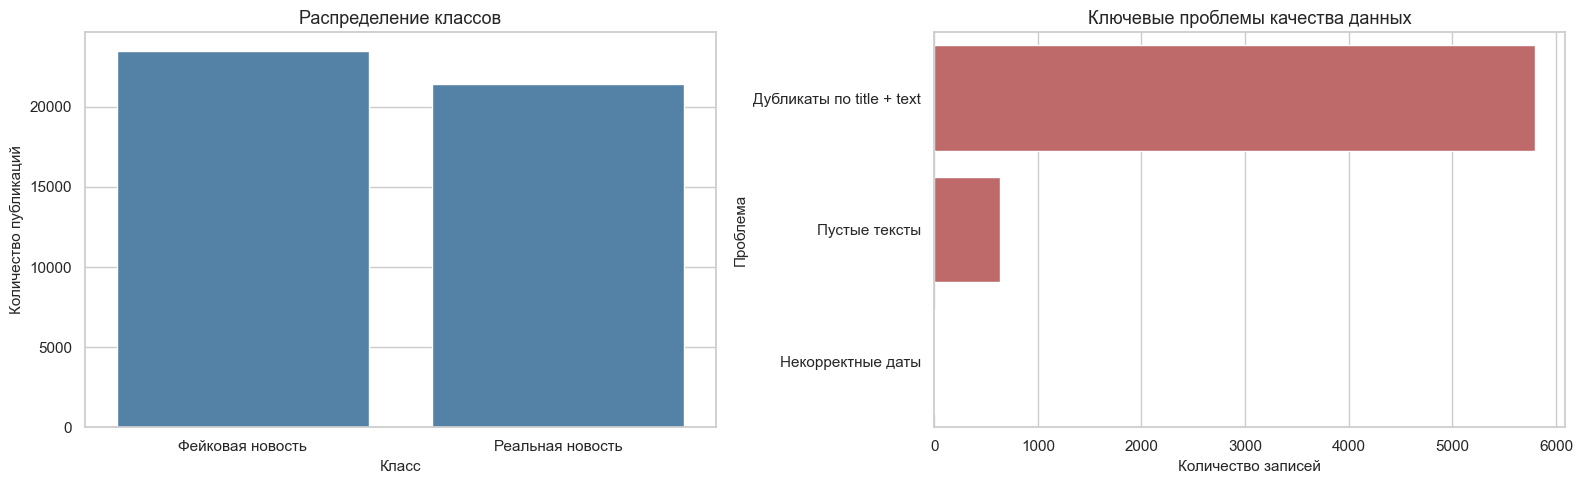

In [14]:
problem_table = pd.DataFrame(
    {
        "Проблема": [
            "Дубликаты по title + text",
            "Пустые тексты",
            "Некорректные даты",
        ],
        "Количество": [
            duplicate_texts,
            empty_text_count,
            unparsed_date_count,
        ],
    }
)

plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=data, x="label_ru", order=["Фейковая новость", "Реальная новость"], color="steelblue")
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество публикаций")

plt.subplot(1, 2, 2)
sns.barplot(data=problem_table, x="Количество", y="Проблема", color="indianred")
plt.title("Ключевые проблемы качества данных")
plt.xlabel("Количество записей")
plt.ylabel("Проблема")

plt.tight_layout()
plt.show()

### Интерпретация базовых статистик

Классы распределены достаточно ровно: фейковые новости составляют 52.3% датасета, а реальные — 47.7%. Это означает, что задача не сводится к тривиальному угадыванию доминирующего класса, но бизнес-смысл всё равно требует ориентироваться прежде всего на `Recall` и `F1-score` для класса `fake`.

Вторая визуализация показывает уже не формальные `NaN`, а реальные проблемы корпуса. Наиболее крупный дефект — 5793 дубликата по `title + text`; кроме этого, обнаружены 631 пустой текст и 10 некорректных значений в поле `date`. Следовательно, качество набора ограничивается не пропусками в табличном смысле, а артефактами сборки данных, и именно их нужно учитывать перед моделированием.

Среднее                                   \
                 text_char_count text_word_count title_char_count   
label_ru                                                            
Реальная новость         2383.28          385.64            64.67   
Фейковая новость         2547.40          423.20            94.20   

                                          Медиана                  \
                 title_word_count text_char_count text_word_count   
label_ru                                                            
Реальная новость             9.95          2222.0           359.0   
Фейковая новость            14.73          2166.0           363.0   

                                                                Q1  \
                 title_char_count title_word_count text_char_count   
label_ru                                                             
Реальная новость             64.0             10.0           914.0   
Фейковая новость             90.0             14.0          1433.0   

                                                                    \
                 text_word_count title_char_count title_word_count   
label_ru                                                             
Реальная новость           148.0             59.0              9.0   
Фейковая новость           240.0             77.0             12.0   

                              Q3                                   \
                 text_char_count text_word_count title_char_count   
label_ru                                                            
Реальная новость          3237.0           525.0             70.0   
Фейковая новость          3032.0           506.0            105.0   

                                   
                 title_word_count  
label_ru                           
Реальная новость             11.0  
Фейковая новость             17.0

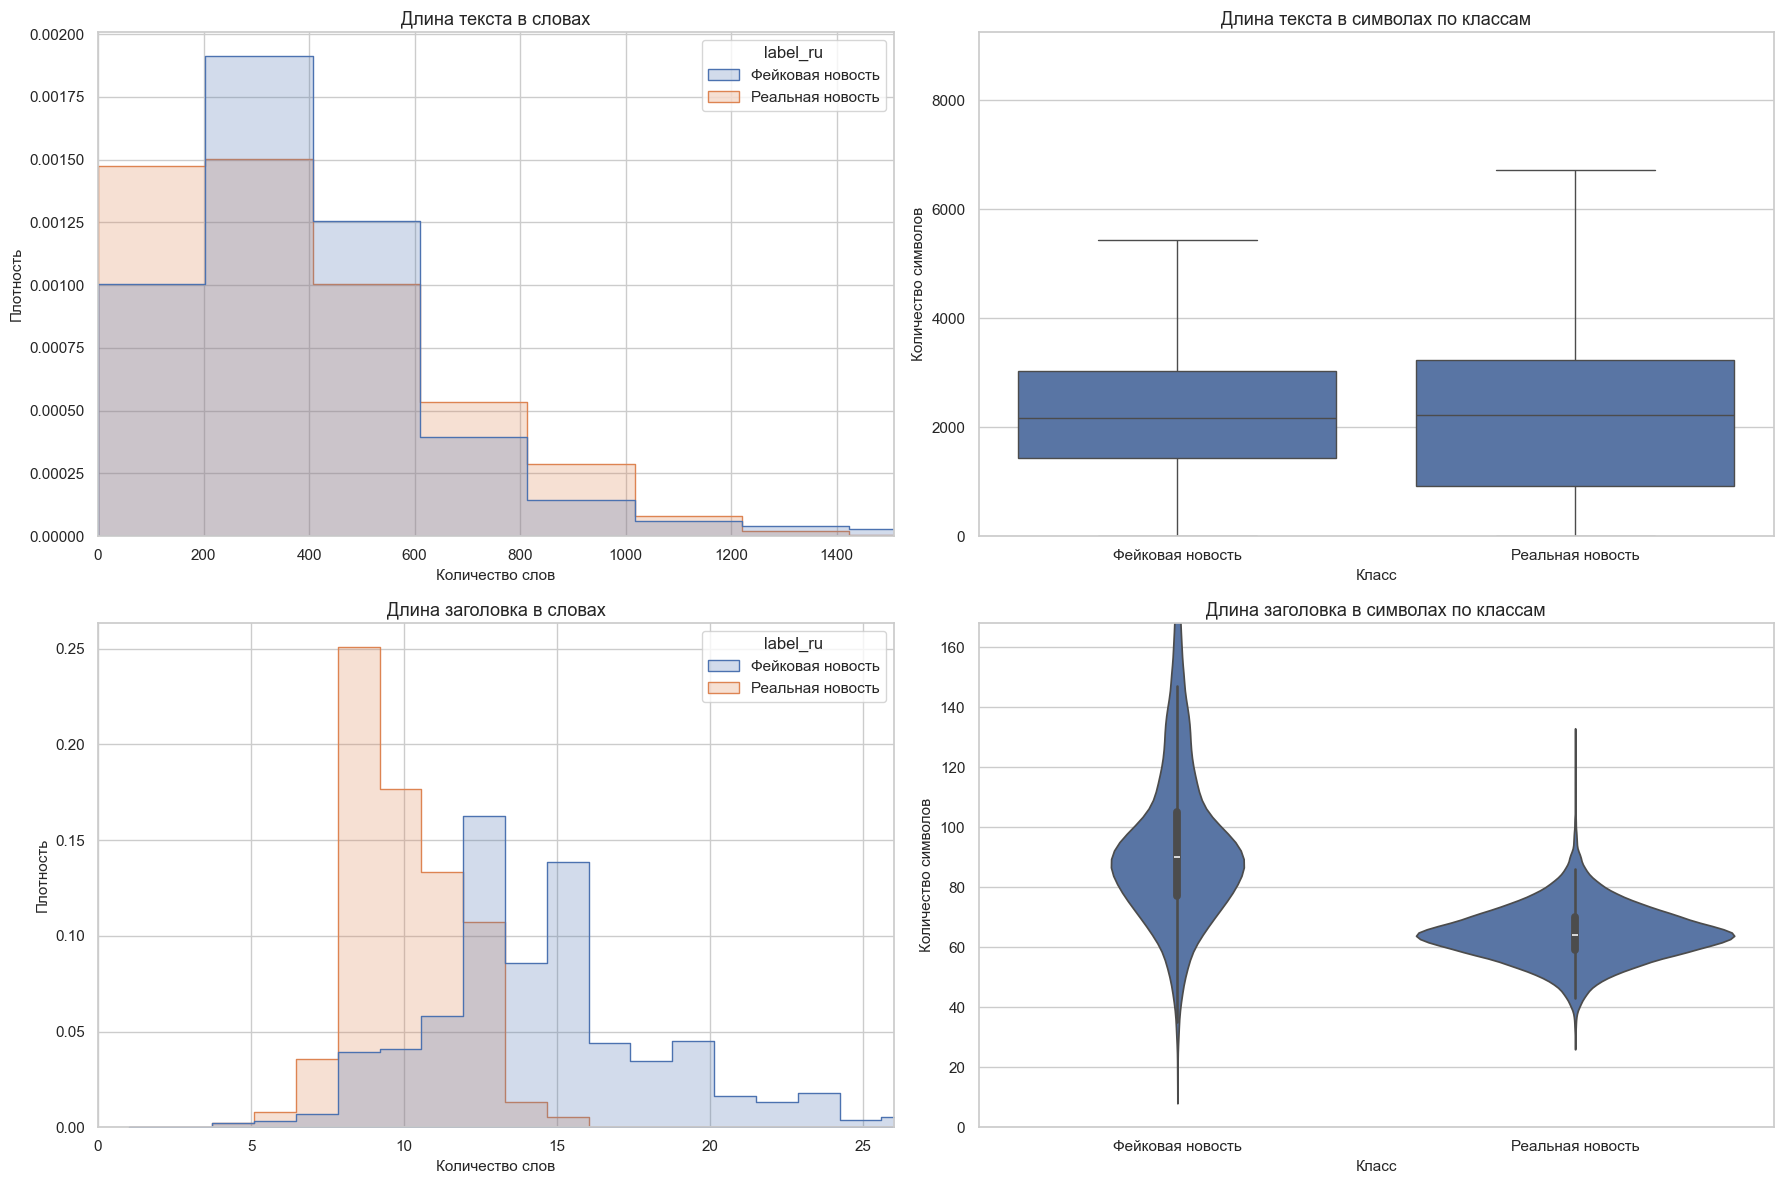

In [15]:
mean_table = data.groupby("label_ru")[["text_char_count", "text_word_count", "title_char_count", "title_word_count"]].mean().round(2)
median_table = data.groupby("label_ru")[["text_char_count", "text_word_count", "title_char_count", "title_word_count"]].median().round(2)
q1_table = data.groupby("label_ru")[["text_char_count", "text_word_count", "title_char_count", "title_word_count"]].quantile(0.25).round(2)
q3_table = data.groupby("label_ru")[["text_char_count", "text_word_count", "title_char_count", "title_word_count"]].quantile(0.75).round(2)

length_table = pd.concat(
    {
        "Среднее": mean_table,
        "Медиана": median_table,
        "Q1": q1_table,
        "Q3": q3_table,
    },
    axis=1,
)

display(length_table)

text_word_limit = data["text_word_count"].quantile(0.99)
title_word_limit = data["title_word_count"].quantile(0.99)
text_char_limit = data["text_char_count"].quantile(0.99)
title_char_limit = data["title_char_count"].quantile(0.99)

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
sns.histplot(data=data, x="text_word_count", hue="label_ru", bins=40, element="step", stat="density", common_norm=False)
plt.xlim(0, text_word_limit)
plt.title("Длина текста в словах")
plt.xlabel("Количество слов")
plt.ylabel("Плотность")

plt.subplot(2, 2, 2)
sns.boxplot(data=data, x="label_ru", y="text_char_count", order=["Фейковая новость", "Реальная новость"], showfliers=False)
plt.ylim(0, text_char_limit)
plt.title("Длина текста в символах по классам")
plt.xlabel("Класс")
plt.ylabel("Количество символов")

plt.subplot(2, 2, 3)
sns.histplot(data=data, x="title_word_count", hue="label_ru", bins=30, element="step", stat="density", common_norm=False)
plt.xlim(0, title_word_limit)
plt.title("Длина заголовка в словах")
plt.xlabel("Количество слов")
plt.ylabel("Плотность")

plt.subplot(2, 2, 4)
sns.violinplot(data=data, x="label_ru", y="title_char_count", order=["Фейковая новость", "Реальная новость"], cut=0)
plt.ylim(0, title_char_limit)
plt.title("Длина заголовка в символах по классам")
plt.xlabel("Класс")
plt.ylabel("Количество символов")

plt.tight_layout()
plt.show()

### Интерпретация текстовых признаков

Для основного текста различия между классами есть, но они не дают простого разделения по одной длине. Средняя длина `fake`-текстов составляет 423.20 слова, медианная — 363 слова, а межквартильный диапазон лежит между 240 и 506 словами. Для `real`-новостей аналогичные значения равны 385.64 слова, 359 слов и интервалу от 148 до 525 слов. Это указывает на сильное перекрытие распределений: фейковые тексты в среднем немного длиннее, но длина текста сама по себе не отделяет классы надёжно.

По числу символов картина остаётся близкой. У `fake` средняя длина текста равна 2547.40 символа, медианная — 2166, квартильный интервал — от 1433 до 3032 символов. У `real` среднее значение составляет 2383.28 символа, медиана — 2222, а интервал между первым и третьим квартилями — от 914 до 3237 символов. Следовательно, полезный сигнал здесь есть, но он связан скорее с общей структурой текста и должен рассматриваться только вместе с содержанием.

Гораздо сильнее различаются заголовки. Для `fake` средняя длина заголовка составляет 94.20 символа и 14.73 слова, медианные значения — 90 символов и 14 слов, а межквартильные интервалы равны 77–105 символам и 12–17 словам. Для `real` соответствующие показатели равны 64.67 символа и 9.95 слова в среднем, 64 символам и 10 словам по медиане, а межквартильные интервалы составляют 59–70 символов и 9–11 слов. Это указывает на более длинную и, вероятно, более экспрессивную подачу в заголовках фейковых новостей, поэтому признаки заголовка выглядят особенно полезными для baseline-модели.

label_ru,Реальная новость,Фейковая новость
subject,,
Government News,0,1570
Middle-east,0,778
News,0,9050
US_News,0,783
left-news,0,4459
politics,0,6841
politicsNews,11272,0
worldnews,10145,0


label_ru,Реальная новость,Фейковая новость
subject,,
Government News,0.0,1.0
Middle-east,0.0,1.0
News,0.0,1.0
US_News,0.0,1.0
left-news,0.0,1.0
politics,0.0,1.0
politicsNews,1.0,0.0
worldnews,1.0,0.0


,Тема,Максимальная доля одного класса
0,Government News,1.0
1,Middle-east,1.0
2,News,1.0
3,US_News,1.0
4,left-news,1.0
5,politics,1.0
6,politicsNews,1.0
7,worldnews,1.0


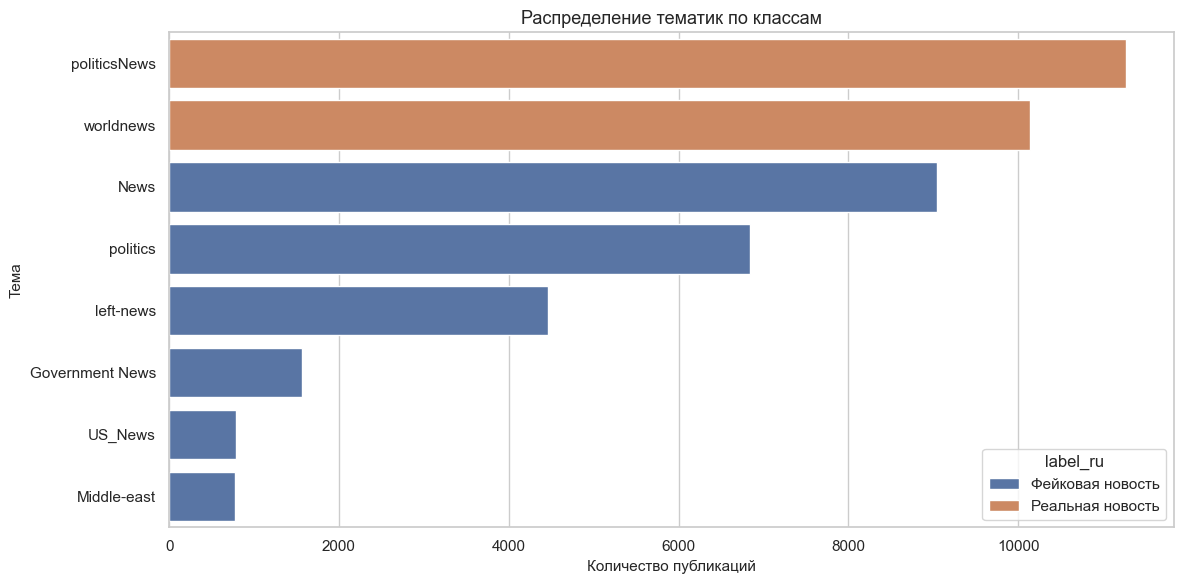

In [16]:
subject_table = pd.crosstab(data["subject"], data["label_ru"])
subject_share_table = pd.crosstab(data["subject"], data["label_ru"], normalize="index")
subject_share_table = subject_share_table.round(2)
subject_purity = subject_share_table.max(axis=1).reset_index()
subject_purity.columns = ["Тема", "Максимальная доля одного класса"]

display(subject_table)
display(subject_share_table)
display(subject_purity)

top_subjects = data["subject"].value_counts().head(8).index
subject_data = data[data["subject"].isin(top_subjects)]

plt.figure(figsize=(12, 6))
sns.countplot(data=subject_data, y="subject", hue="label_ru", order=top_subjects)
plt.title("Распределение тематик по классам")
plt.xlabel("Количество публикаций")
plt.ylabel("Тема")
plt.tight_layout()
plt.show()


### Интерпретация признака `subject`

Здесь выявлена не гипотеза, а установленный факт для данного датасета. Тематические категории не просто связаны с таргетом, а фактически полностью определяют его: для каждой темы максимальная доля одного класса равна 1.00. Это означает почти идеальную утечку таргета.

Следствие однозначно: использовать `subject` в честной модели нельзя. Если оставить этот признак в данных, модель будет распознавать не фейковость текста, а структуру разметки конкретного корпуса. Для корректного baseline-моделирования этот столбец должен быть исключён полностью.

Нормированные частоты слов в заголовках фейковых новостей:


,Слово,На 1000 заголовков
0,trump,397.68
1,video,361.02
2,obama,109.96
3,hillary,98.89
4,watch,82.49
5,president,48.81
6,clinton,48.46
7,new,38.54
8,black,38.16
9,breaking,38.16


Нормированные частоты слов в заголовках реальных новостей:


,Слово,На 1000 заголовков
0,trump,227.62
1,says,139.19
2,house,67.24
3,north,43.19
4,russia,40.34
5,new,40.25
6,korea,38.33
7,white,38.05
8,senate,34.51
9,court,33.20


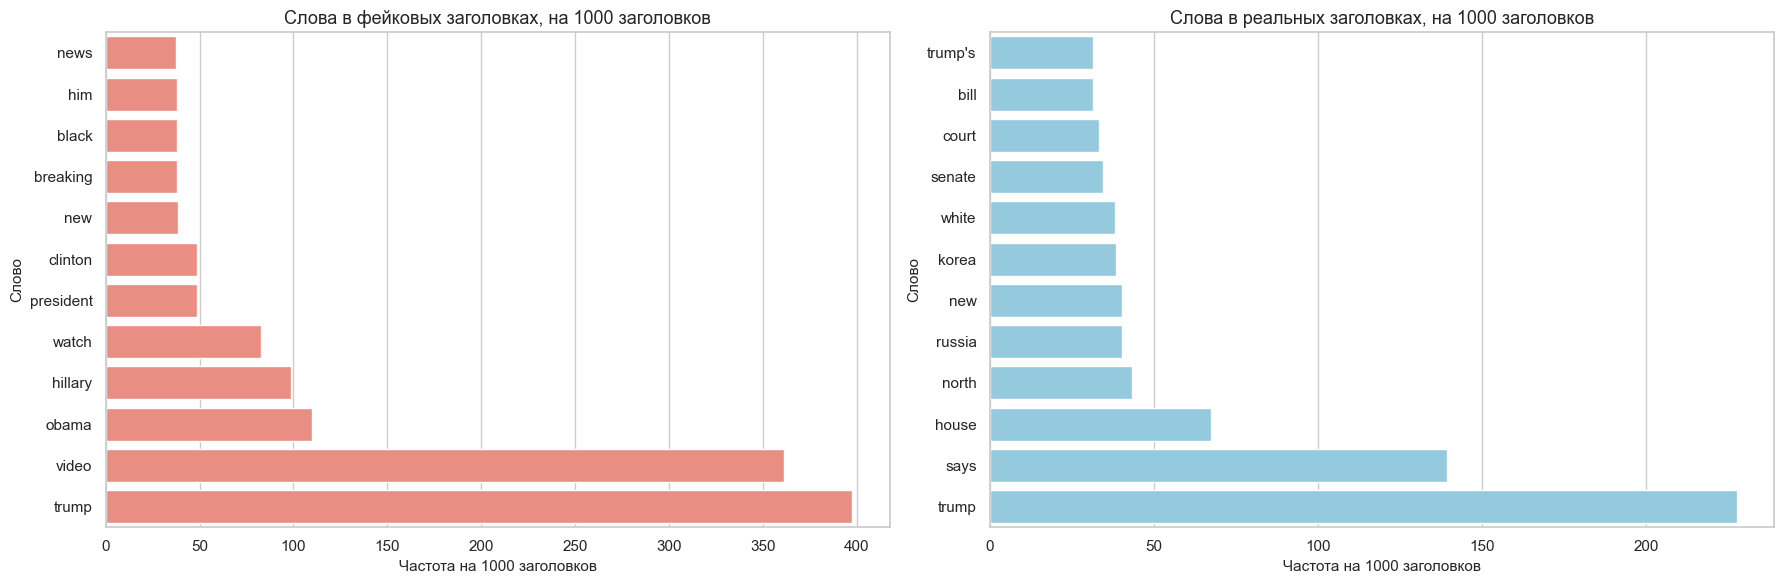

In [17]:
stop_words = {
    "the", "to", "and", "of", "a", "in", "that", "is", "for", "on", "it", "as", "with",
    "its", "was", "are", "at", "by", "be", "this", "from", "an", "have", "has", "will",
    "but", "not", "they", "he", "she", "you", "we", "their", "his", "her", "or", "were",
    "had", "after", "about", "who", "more", "would", "what", "when", "which", "one", "all",
    "out", "can", "just", "our", "also", "if", "than", "into", "over", "up", "no", "do",
    "so", "them", "been", "because", "there", "could", "how", "why", "some", "any",
    "these", "those", "now", "only", "other", "did"
}

fake_titles = data.loc[data["label"] == "fake", "title"].fillna("")
real_titles = data.loc[data["label"] == "real", "title"].fillna("")

fake_counter = Counter()
for title in fake_titles:
    title = title.lower()
    words = re.findall(r"[a-z']+", title)
    for word in words:
        if len(word) > 2 and word not in stop_words:
            fake_counter[word] += 1

real_counter = Counter()
for title in real_titles:
    title = title.lower()
    words = re.findall(r"[a-z']+", title)
    for word in words:
        if len(word) > 2 and word not in stop_words:
            real_counter[word] += 1

fake_top_words = pd.DataFrame(fake_counter.most_common(12), columns=["Слово", "Количество"])
real_top_words = pd.DataFrame(real_counter.most_common(12), columns=["Слово", "Количество"])

fake_top_words["На 1000 заголовков"] = fake_top_words["Количество"] / len(fake_titles) * 1000
real_top_words["На 1000 заголовков"] = real_top_words["Количество"] / len(real_titles) * 1000

fake_top_words["На 1000 заголовков"] = fake_top_words["На 1000 заголовков"].round(2)
real_top_words["На 1000 заголовков"] = real_top_words["На 1000 заголовков"].round(2)

fake_top_words = fake_top_words[["Слово", "На 1000 заголовков"]]
real_top_words = real_top_words[["Слово", "На 1000 заголовков"]]

print("Нормированные частоты слов в заголовках фейковых новостей:")
display(fake_top_words)

print("Нормированные частоты слов в заголовках реальных новостей:")
display(real_top_words)

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=fake_top_words.sort_values("На 1000 заголовков"), x="На 1000 заголовков", y="Слово", color="salmon")
plt.title("Слова в фейковых заголовках, на 1000 заголовков")
plt.xlabel("Частота на 1000 заголовков")
plt.ylabel("Слово")

plt.subplot(1, 2, 2)
sns.barplot(data=real_top_words.sort_values("На 1000 заголовков"), x="На 1000 заголовков", y="Слово", color="skyblue")
plt.title("Слова в реальных заголовках, на 1000 заголовков")
plt.xlabel("Частота на 1000 заголовков")
plt.ylabel("Слово")

plt.tight_layout()
plt.show()

### Интерпретация частотных слов

Этот фрагмент анализа нужно трактовать как вспомогательный исследовательский срез, а не как строгий причинный вывод. Здесь сравнение проводится по **нормированной частоте на 1000 заголовков внутри каждого класса**, поэтому результат не зависит от того, что в корпусе немного больше фейковых заголовков, чем реальных.

После такой нормировки сохраняется та же качественная картина. В обоих классах встречается общая политическая лексика, например `trump`, что ожидаемо для корпуса, связанного с американской повесткой 2016–2017 годов. При этом в заголовках `fake` заметнее слова `video`, `watch`, `obama`, `hillary`, `breaking`, а в `real` чаще встречаются `house`, `north`, `russia`, `korea`, `senate`, `court`. Для данного набора это выглядит как различие между более кликабельной событийной подачей и более институциональной новостной лексикой.

Важно учитывать ограничение этого анализа: лемматизация не выполнялась, используется только unigram-подход, а сами частоты считаются только по заголовкам, а не по полному тексту. Поэтому результаты следует трактовать как обзорный исследовательский сигнал, а не как основной источник выводов о различиях между классами.

Распределение публикаций по годам:


,year,label_ru,Количество публикаций
0,2015,Фейковая новость,2479
1,2016,Реальная новость,4716
2,2016,Фейковая новость,11754
3,2017,Реальная новость,16701
4,2017,Фейковая новость,9203
5,2018,Фейковая новость,35


Месяцы с наибольшим числом публикаций по классам:


,month,label_ru,Количество публикаций
0,2017-10-01,Реальная новость,3172
1,2017-11-01,Реальная новость,3096
2,2017-09-01,Реальная новость,3074
3,2016-03-01,Фейковая новость,1088
4,2016-10-01,Фейковая новость,1082
5,2016-01-01,Фейковая новость,1081


Схема временной валидации на очищенном наборе:


,Период,Начало,Конец,Количество записей,fake,real,"Доля fake, %"
0,train,2015-01-01,2017-06-30,23065,14763,8302,64.01
1,validation,2017-07-01,2017-09-30,5812,1565,4247,26.93
2,test,2017-10-01,2017-12-31,9740,1093,8647,11.22


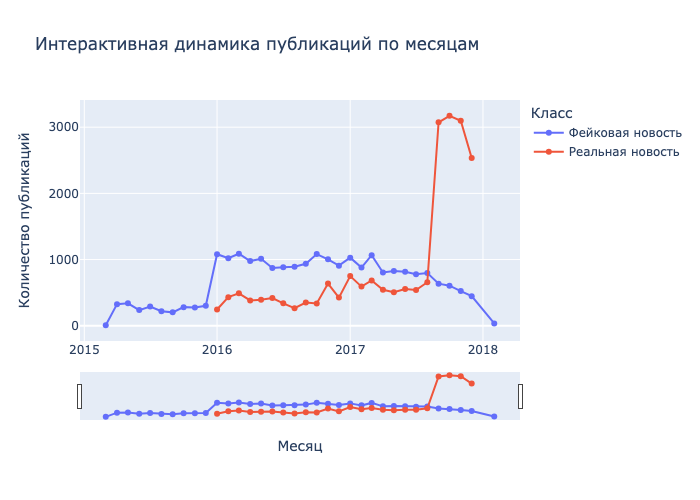

In [18]:
monthly_counts = data.dropna(subset=["date_parsed"]).copy()
monthly_counts["month"] = monthly_counts["date_parsed"].dt.to_period("M").dt.to_timestamp()
monthly_counts = monthly_counts.groupby(["month", "label_ru"]).size().reset_index(name="Количество публикаций")

yearly_counts = data.dropna(subset=["date_parsed"]).copy()
yearly_counts["year"] = yearly_counts["date_parsed"].dt.year
yearly_counts = yearly_counts.groupby(["year", "label_ru"]).size().reset_index(name="Количество публикаций")

peak_months_table = monthly_counts.sort_values(["label_ru", "Количество публикаций"], ascending=[True, False])
peak_months_table = peak_months_table.groupby("label_ru").head(3).reset_index(drop=True)

temporal_validation_data = data.copy()
temporal_validation_data = temporal_validation_data[temporal_validation_data["text"].fillna("").astype(str).str.strip() != ""].copy()
temporal_validation_data = temporal_validation_data[temporal_validation_data["date_parsed"].notna()].copy()
temporal_validation_data = temporal_validation_data.drop_duplicates(subset=["title", "text"]).copy()

temporal_windows = [
    ["train", pd.Timestamp("2015-01-01"), pd.Timestamp("2017-06-30")],
    ["validation", pd.Timestamp("2017-07-01"), pd.Timestamp("2017-09-30")],
    ["test", pd.Timestamp("2017-10-01"), pd.Timestamp("2017-12-31")],
]

temporal_split_rows = []
for period_name, period_start, period_end in temporal_windows:
    period_data = temporal_validation_data[
        (temporal_validation_data["date_parsed"] >= period_start)
        & (temporal_validation_data["date_parsed"] <= period_end)
    ].copy()
    fake_count = (period_data["label"] == "fake").sum()
    real_count = (period_data["label"] == "real").sum()
    temporal_split_rows.append(
        {
            "Период": period_name,
            "Начало": period_start.date(),
            "Конец": period_end.date(),
            "Количество записей": len(period_data),
            "fake": fake_count,
            "real": real_count,
            "Доля fake, %": round(fake_count / len(period_data) * 100, 2),
        }
    )

temporal_split_table = pd.DataFrame(temporal_split_rows)

print("Распределение публикаций по годам:")
display(yearly_counts)

print("Месяцы с наибольшим числом публикаций по классам:")
display(peak_months_table)

print("Схема временной валидации на очищенном наборе:")
display(temporal_split_table)

interactive_figure = px.line(
    monthly_counts,
    x="month",
    y="Количество публикаций",
    color="label_ru",
    markers=True,
    title="Интерактивная динамика публикаций по месяцам",
    labels={
        "month": "Месяц",
        "label_ru": "Класс",
    },
)
interactive_figure.update_layout(
    hovermode="x unified",
    legend_title_text="Класс",
)
interactive_figure.update_xaxes(rangeslider_visible=True)

interactive_figure.show()
interactive_figure.show("png")

### Интерпретация временной динамики

Временное распределение публикаций по классам резко неравномерно. Реальные новости сильно сосредоточены в 2017 году: среди корректно распознанных дат на этот год приходится 16701 публикация класса `real`, тогда как на 2016 год — только 4716. У фейковых новостей картина иная: 11754 записи относятся к 2016 году и 9203 — к 2017 году. Это означает, что календарная структура классов различается, и модель может частично использовать временное смещение корпуса вместо устойчивых текстовых закономерностей.

Пики активности у классов тоже различаются не только по уровню, но и по периоду. Для `real` максимумы приходятся на сентябрь–ноябрь 2017 года: 3074, 3172 и 3096 публикаций в месяц. Для `fake` крупнейшие пики наблюдаются в январе, марте и октябре 2016 года: 1081, 1088 и 1082 публикации соответственно. Кроме того, в 2015 году в датированных данных присутствуют только фейковые новости, а в 2018 году встречается лишь небольшой остаток фейковых публикаций. Для данного датасета это уже установленный факт временной неоднородности, а не второстепенное наблюдение.

Мини-таблица по временным окнам показывает, что выбранное деление остаётся и хронологическим, и рабочим по размеру выборок: `train` содержит 23065 записей, `validation` — 5812, `test` — 9740. Такое разбиение разумно, потому что обучение идёт на самом раннем и самом длинном интервале, следующий по времени блок используется для подбора порога и настройки, а самый поздний крупный интервал — для финальной оценки. Небольшой хвост начала 2018 года в объёме 35 записей слишком мал для основного теста, поэтому его корректно оставить только как дополнительную стресс-проверку.

При таком prior shift необходимо дополнительно контролировать устойчивость выбранного порога между временными окнами. Порог, подобранный на `validation`, может заметно деградировать на более позднем `test`, поэтому его переносимость по времени должна проверяться явно, а не предполагаться автоматически.

Отсюда следует жёсткий методический вывод: итоговую проверку качества нельзя ограничивать только случайным разбиением. На этом корпусе необходимо валидировать модель не только на обычном random split, но и на временном разбиении, где обучение проводится на более ранних периодах, а тестирование — на более поздних. Иначе метрики могут оказаться завышенными за счёт знания календарной структуры датасета, а не за счёт реального умения распознавать фейковые новости.

### Формирование итогового датасета для моделирования и валидации

In [19]:
model_data = data.copy()
model_data["date"] = model_data["date_parsed"]

columns_to_drop = [
    "subject",
    "source_file",
    "label_ru",
    "date_clean",
    "date_parsed",
    "text_char_count",
    "text_word_count",
    "title_char_count",
    "title_word_count",
]
existing_columns_to_drop = []
for column in columns_to_drop:
    if column in model_data.columns:
        existing_columns_to_drop.append(column)

model_data = model_data.drop(columns=existing_columns_to_drop)

rows_before_cleaning = len(model_data)
model_data = model_data[model_data["text"].fillna("").astype(str).str.strip() != ""].copy()
rows_after_empty_text_filter = len(model_data)

model_data = model_data[model_data["date"].notna()].copy()
rows_after_date_filter = len(model_data)

model_data = model_data.drop_duplicates(subset=["title", "text"]).copy()
rows_after_duplicate_filter = len(model_data)

final_columns = ["title", "text", "date", "label"]
existing_final_columns = []
for column in final_columns:
    if column in model_data.columns:
        existing_final_columns.append(column)
model_data = model_data[existing_final_columns].copy()

model_summary = make_summary_table(
    [
        "Количество строк до очистки",
        "Удалено строк с пустым текстом",
        "Удалено строк с некорректной датой",
        "Удалено дубликатов после фильтрации",
        "Количество строк после очистки",
        "Удалены признаки subject и source_file",
        "Удалены служебные и аналитические колонки EDA",
    ],
    [
        rows_before_cleaning,
        rows_before_cleaning - rows_after_empty_text_filter,
        rows_after_empty_text_filter - rows_after_date_filter,
        rows_after_date_filter - rows_after_duplicate_filter,
        rows_after_duplicate_filter,
        "да",
        "да",
    ],
)

model_columns_table = pd.DataFrame(
    {
        "Колонка": ["title", "text", "date", "label"],
        "Роль": [
            "Текстовый признак baseline-модели",
            "Текстовый признак baseline-модели",
            "Нормализованная дата для временной валидации",
            "Целевая переменная",
        ],
    }
)

model_class_distribution = model_data["label"].value_counts().reset_index()
model_class_distribution.columns = ["Класс", "Количество"]
model_class_distribution["Доля, %"] = model_class_distribution["Количество"] / len(model_data) * 100
model_class_distribution["Доля, %"] = model_class_distribution["Доля, %"].round(2)

print("Итоговый датасет для моделирования и валидации:")
display(model_summary)

print("Итоговый состав колонок:")
display(model_columns_table)

print("Распределение классов после очистки:")
display(model_class_distribution)

print("Первые строки итогового набора:")
display(model_data.head())

Итоговый датасет для моделирования и валидации:


,Показатель,Значение
0,Количество строк до очистки,44898
1,Удалено строк с пустым текстом,631
2,Удалено строк с некорректной датой,10
3,Удалено дубликатов после фильтрации,5605
4,Количество строк после очистки,38652
5,Удалены признаки subject и source_file,да
6,Удалены служебные и аналитические колонки EDA,да


Итоговый состав колонок:


,Колонка,Роль
0,title,Текстовый признак baseline-модели
1,text,Текстовый признак baseline-модели
2,date,Нормализованная дата для временной валидации
3,label,Целевая переменная


Распределение классов после очистки:


,Класс,Количество,"Доля, %"
0,real,21196,54.84
1,fake,17456,45.16


Первые строки итогового набора:


,title,text,date,label
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",2017-12-31,fake
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",2017-12-31,fake
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Securit...",2017-12-30,fake
3,Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES),"On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for th...",2017-12-29,fake
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech,Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope...,2017-12-25,fake


### Интерпретация подготовки датасета для моделирования и валидации

На этом шаге сформирован уже не просто очищенный аналитический набор, а корректный датасет для следующего этапа моделирования. Из него удалены `subject` и `source_file`, потому что они связаны с происхождением записи и могут давать утечку таргета. Также исключены служебные колонки и признаки, созданные только для EDA: `label_ru`, `date_clean`, `date_parsed`, а также длины текста и заголовка. После этого в итоговом наборе остаются только `title`, `text`, `date` и `label`.

Такой состав колонок методически корректен для baseline-постановки. Поля `title` и `text` являются прямыми текстовыми источниками признаков, `label` задаёт целевую переменную, а `date` сохранена в нормализованном виде специально для обязательной временной валидации. Поскольку дата нужна для честной проверки модели, 10 строк с некорректной датой удалены из итогового набора. После всей очистки размер корпуса уменьшается с 44898 до 38652 строк: удаляются 631 запись с пустым текстом, 10 строк с некорректной датой и ещё 5605 дубликатов после фильтрации. Итоговый датасет остаётся достаточно большим для baseline-модели и уже соответствует текущей постановке задачи.

## 8. Выводы и рекомендации по дальнейшей предобработке и моделированию

В работе сформулирована прикладная бизнес-постановка задачи: модель должна использоваться как инструмент предварительной фильтрации контента и помогать модерации перехватывать опасные публикации до их распространения. В ML-терминах это корректная задача бинарной классификации с положительным классом `fake`. Для данного процесса критичнее пропуск фейковой новости, поэтому качество модели нужно контролировать прежде всего по `Recall(fake)` и `F1-score(fake)`, а рабочий порог выбирать по заранее зафиксированному правилу: `Recall(fake) >= 0.85`, `Precision(fake) >= 0.75`, а среди таких порогов — максимум `F1-score(fake)`.

Разведочный анализ показал, что исходный корпус подходит для baseline-решения, но содержит несколько существенных ограничений. В наборе обнаружены 5793 дубликата по `title + text`, 631 пустой текст и 10 некорректных дат. Признак `subject` даёт почти идеальную утечку таргета и в рамках данного датасета должен считаться запрещённым для честного моделирования. Анализ длины текстов и особенно заголовков показал, что поверхностные стилевые различия между классами действительно существуют, но основной сигнал должен извлекаться из содержимого текста, а не только из длины. Анализ топ-слов после нормировки на 1000 заголовков полезен как вспомогательная иллюстрация, но его нужно трактовать осторожно: лемматизация не выполнялась, близкие словоформы учитываются отдельно, а анализ основан только на unigram-заголовках.

Наиболее важный методический результат связан со временем. Распределение fake- и real-публикаций по годам и месяцам заметно различается, поэтому итоговую оценку качества нельзя проводить только на случайном разбиении. План проверки модели должен быть временным и фиксированным заранее:
1. `train`: все корректно датированные публикации с января 2015 года по июнь 2017 года;
2. `validation`: публикации с июля по сентябрь 2017 года;
3. `test`: публикации с октября по декабрь 2017 года.

Такое деление опирается на очищенный корпус и даёт непустые, достаточно крупные окна: 23065 записей в `train`, 5812 в `validation` и 9740 в `test`. Эта схема не допускает утечки информации из будущего в обучение и даёт более реалистичную оценку качества модели на новых публикациях. Небольшой хвост начала 2018 года целесообразно использовать только как дополнительную стресс-проверку, а не как основной тестовый интервал, потому что он слишком мал и несимметричен по классам. Основная и обязательная схема оценки для этого корпуса — temporal split, а random split допустим только как вспомогательная диагностическая проверка.

По итогам работы уже сформирован итоговый датасет для следующего шага: `title`, `text`, `date`, `label`, где колонка `date` приведена к пригодному для валидации формату. Следующий этап должен включать очистку текста, векторизацию `title` и `text` с помощью TF-IDF, построение baseline-модели, например Logistic Regression, и оценку качества по `Recall`, `Precision` и `F1-score` для класса `fake` сначала на обязательном временном разбиении, а затем при необходимости на random split как дополнительной диагностике. В таком виде работа представляет завершённую и методически корректную постановку задачи перед обучением модели.